In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

!unzip -q -o data.zip #Trzeba dodać do plików

1. Definicja Datasetu

In [38]:
class PCamDataset(Dataset):
    def __init__(self, csv_file, transform=None, num_samples=None):
        self.annotations = pd.read_csv(csv_file)
        if num_samples is not None:
            self.annotations = self.annotations.head(num_samples)
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_path = self.annotations.iloc[idx, 0]
        label = self.annotations.iloc[idx, 1]

        image = Image.open(img_path)
        if image.mode != 'RGB':
            image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float)
        return image, label

Zadanie 1:

In [39]:
train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

Zadanie 4:

In [40]:
val_test_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

Zadanie 2, 3 i 5:

In [41]:
train_dataset = PCamDataset(csv_file='data/train_labels.csv', transform=train_transform)
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_dataset = PCamDataset(csv_file='data/validation_labels.csv', transform=val_test_transform)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = PCamDataset(csv_file='data/test_labels.csv', transform=val_test_transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [42]:
print(f"Ilość zdjęć treningowych: {len(train_dataset)}")
print(f"Ilość zdjęć walidacyjnych: {len(val_dataset)}")
print(f"Ilość zdjęć testowych: {len(test_dataset)}")

Ilość zdjęć treningowych: 600
Ilość zdjęć walidacyjnych: 200
Ilość zdjęć testowych: 200


Zadanie 6:

In [43]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)


        self.fc1 = nn.Linear(18432, 256) #128 * 12 * 12
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))

        x = torch.sigmoid(self.fc2(x)).squeeze(1)
        return x

Zadanie 7:

In [44]:
cnn_model = SimpleCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = cnn_model.to(device)

Zadanie 8:

In [45]:
criterion = nn.BCELoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005)

print("Sieć skonstruowana i wysłana na:", device)

Sieć skonstruowana i wysłana na: cuda


Zadanie 9:

Rozpoczynamy trening...
Epoka [1/5] | Błąd treninu (Train Loss): 0.6343 | Błąd walidacji (Val Loss): 0.5749
Epoka [2/5] | Błąd treninu (Train Loss): 0.5715 | Błąd walidacji (Val Loss): 0.5537
Epoka [3/5] | Błąd treninu (Train Loss): 0.5182 | Błąd walidacji (Val Loss): 0.5211
Epoka [4/5] | Błąd treninu (Train Loss): 0.4891 | Błąd walidacji (Val Loss): 0.5191
Epoka [5/5] | Błąd treninu (Train Loss): 0.4956 | Błąd walidacji (Val Loss): 0.5271


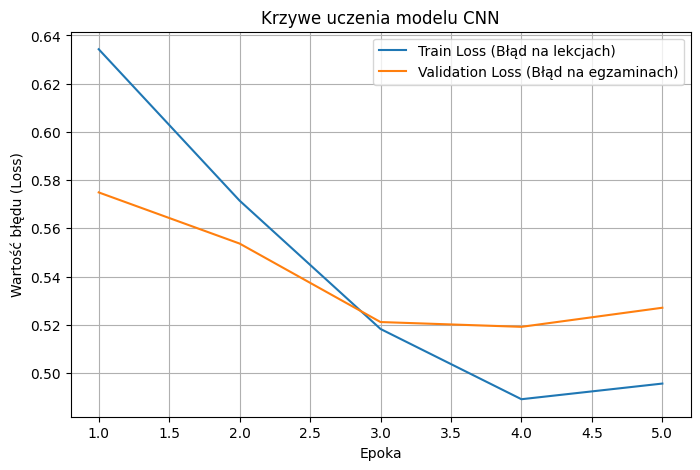

In [46]:
num_epochs = 5
train_losses = []
val_losses = []

print("Rozpoczynamy trening...")

for epoch in range(num_epochs):
    cnn_model.train()
    total_train_loss = 0.0

    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item() * images.size(0)

    avg_train_loss = total_train_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    cnn_model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item() * images.size(0)

    avg_val_loss = total_val_loss / len(val_dataset)
    val_losses.append(avg_val_loss)

    print(f"Epoka [{epoch+1}/{num_epochs}] | Błąd treninu (Train Loss): {avg_train_loss:.4f} | Błąd walidacji (Val Loss): {avg_val_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss (Błąd na lekcjach)')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss (Błąd na egzaminach)')
plt.xlabel('Epoka')
plt.ylabel('Wartość błędu (Loss)')
plt.title('Krzywe uczenia modelu CNN')
plt.legend()
plt.grid(True)
plt.show()

Zadanie 10:

In [47]:
cnn_model.eval()

test_pred_probs = []
test_pred_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:

        images = images.to(device)

        outputs = cnn_model(images)

        test_pred_probs.extend(outputs.cpu().numpy())

        pred_labels = torch.round(outputs)

        test_pred_labels.extend(pred_labels.cpu().numpy())

test_pred_probs = np.array(test_pred_probs)
test_pred_labels = np.array(test_pred_labels)

Zadanie 11:

Dokładność (Accuracy): 0.7900

Raport klasyfikacji:
              precision    recall  f1-score   support

Normalne (0)       0.84      0.70      0.76        97
     Guz (1)       0.76      0.87      0.81       103

    accuracy                           0.79       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.79      0.79       200



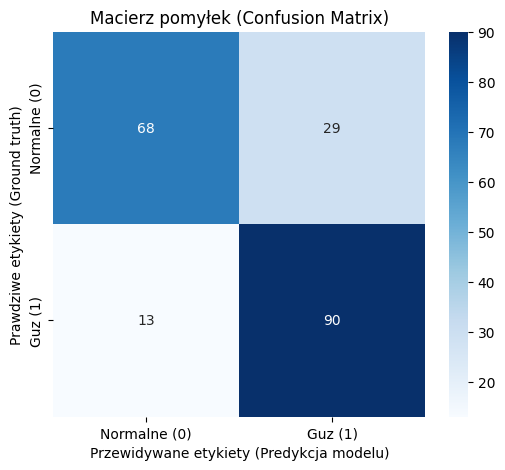

In [48]:
true_labels = []
with torch.no_grad():
    for images, labels in test_dataloader:
        true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

# 2. Obliczenie metryk ewaluacyjnych
accuracy = accuracy_score(true_labels, test_pred_labels)
conf_matrix = confusion_matrix(true_labels, test_pred_labels)
class_report = classification_report(true_labels, test_pred_labels, target_names=['Normalne (0)', 'Guz (1)'])

print(f"Dokładność (Accuracy): {accuracy:.4f}")
print("\nRaport klasyfikacji:")
print(class_report)

# 3. Wizualizacja macierzy pomyłek (Confusion Matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normalne (0)', 'Guz (1)'],
            yticklabels=['Normalne (0)', 'Guz (1)'])
plt.xlabel('Przewidywane etykiety (Predykcja modelu)')
plt.ylabel('Prawdziwe etykiety (Ground truth)')
plt.title('Macierz pomyłek (Confusion Matrix)')
plt.show()